# Variational Autoencoders (VAEs): A Deep Dive

## 1. Probabilistic Framework

VAEs are based on the idea of learning a generative model $p(x)$ for data $x$. We introduce a latent variable $z$ and factorize the joint distribution [1]:

$p(x,z) = p(x|z)p(z)$

The goal is to maximize the marginal likelihood $p(x) = \int p(x|z)p(z)dz$. However, this integral is often intractable.

## 2. Variational Inference

To tackle this, we introduce an approximate posterior $q_\phi(z|x)$ and use Jensen's inequality [2]:

$\log p(x) = \log \int p(x|z)p(z)dz$
$         = \log \int p(x|z)p(z) \frac{q_\phi(z|x)}{q_\phi(z|x)} dz$
$         \geq \int q_\phi(z|x) \log [\frac{p(x|z)p(z)}{q_\phi(z|x)}] dz$
$         = E_{q_\phi(z|x)}[\log p(x|z)] - KL(q_\phi(z|x) || p(z))$
$         = \text{ELBO (Evidence Lower BOund)}$

## 3. Neural Network Parameterization

We parameterize the encoder $q_\phi(z|x)$ and decoder $p_\theta(x|z)$ using neural networks [1]:

- Encoder: $q_\phi(z|x) = N(\mu_\phi(x), \text{diag}(\sigma^2_\phi(x)))$
  Where $\mu_\phi(x)$ and $\sigma_\phi(x)$ are neural networks with parameters $\phi$.

- Decoder: $p_\theta(x|z) = f(x; g_\theta(z))$
  Where $g_\theta(z)$ is a neural network with parameters $\theta$, and $f$ is an appropriate probability distribution.

## 4. Reparameterization Trick

To allow backpropagation through the sampling process, we use the reparameterization trick [1]:

$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \text{ where } \epsilon \sim N(0, I)$

This allows us to express the expectation over $q_\phi(z|x)$ as an expectation over $\epsilon$, which doesn't depend on $\phi$.

## 5. Detailed ELBO

Expanding the ELBO:

$\text{ELBO} = E_{q_\phi(z|x)}[\log p_\theta(x|z)] - KL(q_\phi(z|x) || p(z))$
$     = E_{\epsilon\sim N(0,I)}[\log p_\theta(x|\mu_\phi(x) + \sigma_\phi(x) \odot \epsilon)] - KL(N(\mu_\phi(x), \text{diag}(\sigma^2_\phi(x))) || N(0, I))$

The KL divergence term has a closed-form solution:

$KL(N(\mu, \text{diag}(\sigma^2)) || N(0, I)) = -0.5 \sum(1 + \log(\sigma^2_i) - \mu^2_i - \sigma^2_i)$

## 6. Optimization

We maximize the ELBO with respect to both $\phi$ and $\theta$ [3]:

$(\phi^*, \theta^*) = \arg\max_{\phi,\theta} \text{ELBO}(\phi, \theta)$

This is typically done using stochastic gradient descent, approximating expectations with Monte Carlo samples.

## 7. Generating New Data

To generate new data:
1. Sample $z \sim N(0, I)$
2. Generate $x \sim p_\theta(x|z)$

## 8. Disentangled Representations

VAEs can learn disentangled representations by modifying the KL divergence term [4]:

$\text{ELBO}_\beta = E_{q_\phi(z|x)}[\log p_\theta(x|z)] - \beta * KL(q_\phi(z|x) || p(z))$

Where $\beta > 1$ encourages more disentangled latent representations.

## 9. Theoretical Connections

VAEs have connections to other methods:
- When $\beta \to \infty$, VAEs approach Principal Component Analysis (PCA) [5]
- VAEs can be seen as a regularized version of the classical autoencoder [6]

## 10. Extensions

Various extensions exist, including:
- Conditional VAEs: $p(x|y,z)$, useful for supervised tasks [7]
- VQ-VAEs: Using discrete latent variables [8]
- Hierarchical VAEs: Introducing multiple levels of latent variables [9]

## References

[1] Kingma, D. P., & Welling, M. (2013). Auto-encoding variational bayes. arXiv preprint arXiv:1312.6114.

[2] Blei, D. M., Kucukelbir, A., & McAuliffe, J. D. (2017). Variational inference: A review for statisticians. Journal of the American statistical Association, 112(518), 859-877.

[3] Rezende, D. J., Mohamed, S., & Wierstra, D. (2014). Stochastic backpropagation and approximate inference in deep generative models. arXiv preprint arXiv:1401.4082.

[4] Higgins, I., Matthey, L., Pal, A., Burgess, C., Glorot, X., Botvinick, M., ... & Lerchner, A. (2016). beta-VAE: Learning basic visual concepts with a constrained variational framework. ICLR, 2(5), 6.

[5] Rolinek, M., Zietlow, D., & Martius, G. (2019). Variational autoencoders pursue pca directions (by accident). In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (pp. 12406-12415).

[6] Ghosh, P., Sajjadi, M. S., Vergari, A., Black, M., & Schölkopf, B. (2020). From variational to deterministic autoencoders. arXiv preprint arXiv:1903.12436.

[7] Sohn, K., Lee, H., & Yan, X. (2015). Learning structured output representation using deep conditional generative models. Advances in neural information processing systems, 28.

[8] van den Oord, A., Vinyals, O., & Kavukcuoglu, K. (2017). Neural discrete representation learning. arXiv preprint arXiv:1711.00937.

[9] Sønderby, C. K., Raiko, T., Maaløe, L., Sønderby, S. K., & Winther, O. (2016). Ladder variational autoencoders. arXiv preprint arXiv:1602.02282.

In [1]:
!pip install torch==2.0.1 torchvision matplotlib torchviz graphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 46.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 52.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 68.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 51782445.51it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1784530.19it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



...

Epoch 1/20, Loss: -19893.4928
Epoch 2/20, Loss: -30058.4187
Epoch 3/20, Loss: -32488.3433
Epoch 4/20, Loss: -33671.1529
Epoch 5/20, Loss: -34711.2732
Epoch 6/20, Loss: -35481.5177
Epoch 7/20, Loss: -36048.5065
Epoch 8/20, Loss: -36497.0521
Epoch 9/20, Loss: -36806.0380
Epoch 10/20, Loss: -37036.6335
Epoch 11/20, Loss: -37222.7208
Epoch 12/20, Loss: -37391.6222
Epoch 13/20, Loss: -37557.2914
Epoch 14/20, Loss: -37700.2559
Epoch 15/20, Loss: -37797.4609
Epoch 16/20, Loss: -37881.4575
Epoch 17/20, Loss: -37954.9308
Epoch 18/20, Loss: -38011.7092
Epoch 19/20, Loss: -38064.1705
Epoch 20/20, Loss: -38112.6328


[2024-07-22 21:40:54,773] torch._inductor.utils: [WARNING] using triton random, expect difference from eager


Model architecture saved as 'vae_architecture.png'
Generated samples saved as 'vae_generated_samples.png'


[2024-07-22 21:41:03,024] torch._inductor.utils: [WARNING] using triton random, expect difference from eager


Reconstructions saved as 'vae_reconstructions.png'


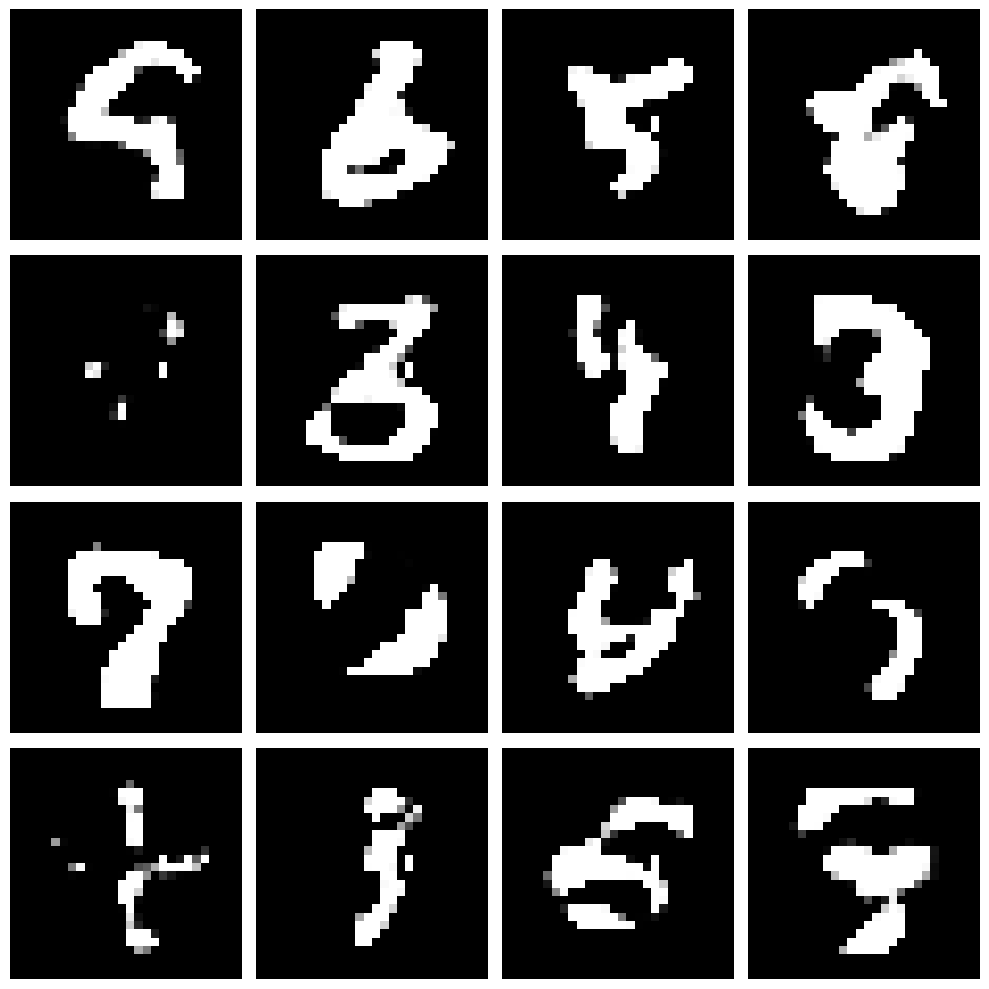

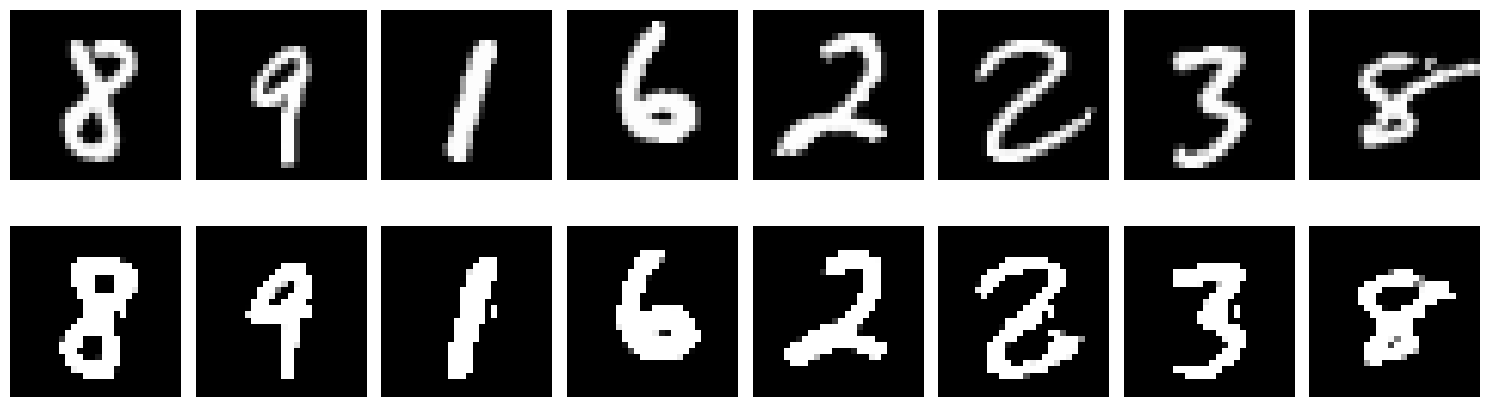

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchviz import make_dot
from typing import Tuple

# Set random seed for reproducibility
torch.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
batch_size = 128
learning_rate = 1e-3
num_epochs = 20
latent_dim = 20

# MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Initialize model
model = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)

# Use torch.compile for performance optimization
model = torch.compile(model)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loss function
def loss_function(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader.dataset):.4f}')

# Visualize model architecture
x = torch.randn(1, 784).to(device)
y, _, _ = model(x)
dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("vae_architecture", format="png")
print("Model architecture saved as 'vae_architecture.png'")

# Generate some samples
model.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    sample = model.decode(z).cpu()

# Display generated samples
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample[i].view(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.savefig('vae_generated_samples.png')
print("Generated samples saved as 'vae_generated_samples.png'")

# Reconstruct some test images
test_loader = DataLoader(
    torchvision.datasets.MNIST(root='./data', train=False, transform=transform),
    batch_size=8, shuffle=True)

data, _ = next(iter(test_loader))
data = data.to(device)
recon, _, _ = model(data)

# Display original and reconstructed images
fig, axes = plt.subplots(2, 8, figsize=(15, 5))
for i in range(8):
    axes[0, i].imshow(data[i].cpu().squeeze().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().view(28, 28).detach().numpy(), cmap='gray')
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('vae_reconstructions.png')
print("Reconstructions saved as 'vae_reconstructions.png'")